In [11]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import lineax as lx

In [12]:
def rhs(t, state, args):

    sigma, rho, beta, noise = args
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return jnp.array([dx, dy, dz])


def lorenz_diffusion(t, state, args):

    _, _, _, noise = args

    return lx.DiagonalLinearOperator(noise)


def measurement_function(state):
    x, y, z = state
    epsilon = 0.0
    return jnp.array([x + epsilon * x**2])

In [13]:
def model(ts,y0,par,key):
  key,w_key = jax.random.split(key)
  brownian_motion = diffrax.VirtualBrownianTree(ts[0],ts[-1], tol=1e-3, shape=(len(y0),), key=w_key)
  terms = diffrax.MultiTerm(ODETerm(rhs), ControlTerm(lorenz_diffusion, brownian_motion))

  solution = diffrax.diffeqsolve(
            terms,
            diffrax.Heun(),
            t0=ts[0],
            t1=ts[-1],
            dt0=0.01,
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts),
        )
  return solution.ys

In [14]:
t_vec = jnp.linspace(0, 10, 500)

rng_key = jax.random.PRNGKey(1)

noise_key, rng_key = jax.random.split(rng_key)

"""Simulate model"""
params = (10.0, 28.0, 8 / 3, 4.0)
x0 = jnp.array([0.0, 0.5, 0.1])

sim_key, rng_key = jax.random.split(rng_key)
full_state = model(t_vec, x0, params, sim_key)

obs_noise_key, rng_key = jax.random.split(rng_key)
obs_noise_std = 1.0
observations = jax.vmap(measurement_function)(full_state) 
observations += obs_noise_std * jax.random.normal(
    obs_noise_key, shape=observations.shape
)

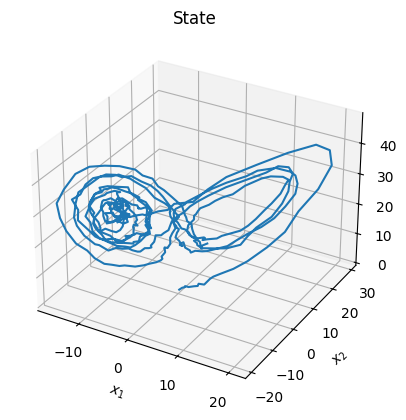

In [15]:
X = full_state

# Plot the first three variables
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.set_title('State')
ax.plot(X[:, 0], X[:, 1], X[:, 2])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
plt.show()

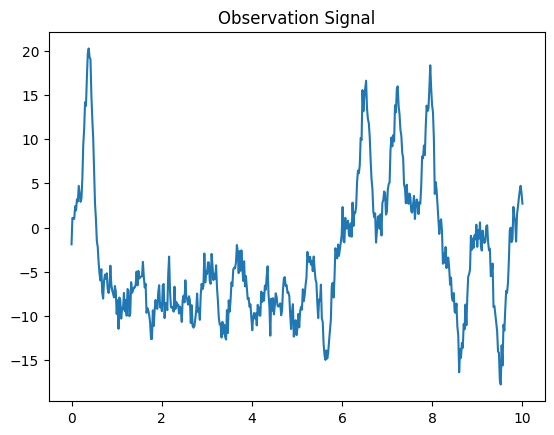

In [16]:
plt.title('Observation Signal')
plt.plot(t_vec, observations)
plt.show()

In [17]:
def ensemble_kalman_filter(
    observations,model, measurement_function, delta_t, initial_ensemble, key, R_obs, params
):
    def kalman_step(state, i):
        prev_ensemble, prev_key = state

        forecast_key, curr_key = jax.random.split(prev_key)
        forecast_keys = jax.random.split(forecast_key, prev_ensemble.shape[0])
        forecast_ensemble = jax.vmap(model, in_axes=(None, 0, None, 0))(
            jnp.linspace(0, delta_t, 10), prev_ensemble, params, forecast_keys
        )[:, -1, :]

        mean = jnp.mean(forecast_ensemble, axis=0)
        state_perturbation_matrix = (
            1 / jnp.sqrt(len(forecast_ensemble) - 1) * (forecast_ensemble - mean)
        ).squeeze()

        obs_ensemble = jax.vmap(measurement_function)(forecast_ensemble)
        obs_mean = jnp.mean(obs_ensemble, axis=0)
        obs_perturbation_matrix = (
            1 / jnp.sqrt(len(forecast_ensemble) - 1) * (obs_ensemble - obs_mean)
        )

        cross_cov = jnp.dot(state_perturbation_matrix.T, obs_perturbation_matrix)

        S = jnp.dot(obs_perturbation_matrix.T, obs_perturbation_matrix) + R_obs
        S_inv = jnp.linalg.pinv(jnp.atleast_2d(S))

        K = jnp.dot(cross_cov, S_inv)

        R_obs_sqrt = jnp.linalg.cholesky(R_obs)

        perturbed_observations_key, curr_key = jax.random.split(curr_key)
        perturbed_observations = observations[i] + jnp.dot(
            jax.random.normal(
                perturbed_observations_key,
                shape=(forecast_ensemble.shape[0], len(observations[i])),
            ),R_obs_sqrt.T
        )

        innovation = perturbed_observations - obs_ensemble

        posterior_ensemble = forecast_ensemble + jnp.dot(innovation,K.T)

        return (posterior_ensemble, curr_key), posterior_ensemble

    return jax.lax.scan(
        kalman_step, (initial_ensemble, key), xs=jnp.arange(0, len(observations))
    )


In [18]:
ensemble_key, rng_key = jax.random.split(rng_key)
num_ensemble_members = 10_000
init_ensemble = jax.random.multivariate_normal(
    ensemble_key,
    mean=jnp.zeros(3),
    cov=0.1 * jnp.eye(3),
    shape=(num_ensemble_members),
)

inflated_obs_noise = 1.0 * jnp.diag(jnp.array([obs_noise_std**2]))


inference_key, rng_key = jax.random.split(rng_key)
_, output = ensemble_kalman_filter(
    observations,
    model,
    measurement_function,
    t_vec[1] - t_vec[0],
    init_ensemble,
    inference_key,
    inflated_obs_noise,
    params,
)

In [19]:
def particle_filter(
    observations, model, delta_t, initial_particles, key, likelihood, theta
):

    num_particles = initial_particles.shape[0]

    def filter_step(state, i):
        prev_particles, prev_key = state

        forecast_key, next_key = jax.random.split(prev_key)
        forecast_keys = jax.random.split(forecast_key, num_particles)

        forecast_particles = jax.vmap(model, in_axes=(None, 0, None, 0))(
            jnp.linspace(0, delta_t, 10), prev_particles, theta, forecast_keys
        )[:, -1, :]

        weights = likelihood(forecast_particles, observations[i])
        resampling_key, next_key = jax.random.split(next_key)
        indices = jax.random.choice(
            resampling_key,
            jnp.arange(0, num_particles),
            p=weights / jnp.sum(weights),
            shape=(num_particles,),
        )

        resampled_particles = forecast_particles[indices, :]

        return (resampled_particles, next_key), resampled_particles

    return jax.lax.scan(
        filter_step, (initial_particles, key), xs=jnp.arange(0, len(observations))
    )


In [20]:
pf_init_key, rng_key = jax.random.split(rng_key)

pf_key, rng_key = jax.random.split(rng_key)

init_ensemble = jax.random.multivariate_normal(
    ensemble_key,
    mean=jnp.zeros(3),
    cov=0.1 * jnp.eye(3),
    shape=(num_ensemble_members),
)


def likelihood(particles, observation):
    return jnp.exp(
        jax.scipy.stats.norm.logpdf(
            observation,
            loc=jax.vmap(measurement_function)(particles),
            scale=obs_noise_std,
        ).sum(axis=1)
    )


_, particles = particle_filter(
    observations, model, t_vec[1] - t_vec[0], init_ensemble, pf_key, likelihood, params
)

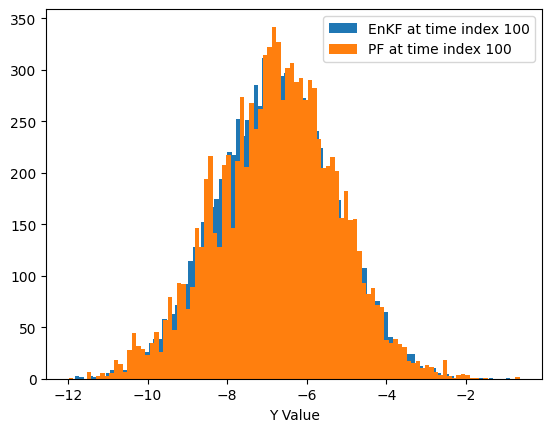

In [21]:
index = 100
state = 1
plt.hist(output[index,:,state],bins = 100,label = f"EnKF at time index {index}")
plt.hist(particles[index,:,state],bins = 100,label = f"PF at time index {index}")
plt.xlabel('Y Value')
plt.legend()
plt.show()

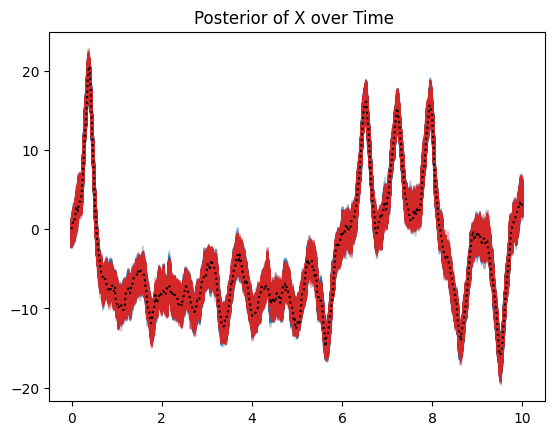

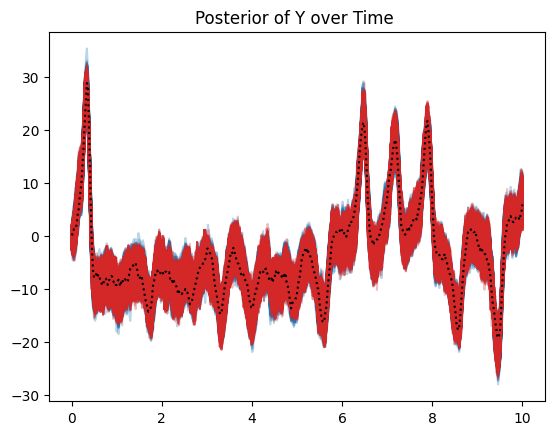

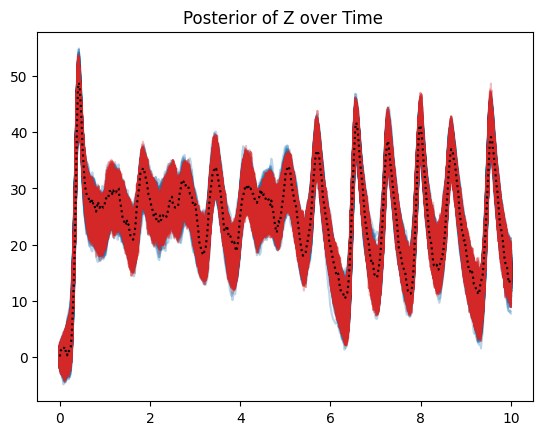

In [22]:
labels = ["X", "Y", "Z"]
for i in range(len(labels)):
    plt.title(f"Posterior of {labels[i]} over Time ")
    plt.plot(t_vec, full_state[:, i], color="black", ls="dotted", zorder=100)
    plt.plot(t_vec, output[:, :, i].squeeze(), color="tab:blue", alpha=0.3)
    plt.plot(t_vec, particles[:, :, i].squeeze(), color="tab:red", alpha=0.3)
    plt.show()

In [23]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation


In [ ]:
# Output generated via `matplotlib.animation.Animation.to_jshtml`.
from IPython.display import HTML
import matplotlib

num_bins = 100
state_var = 0

# bins = np.linspace(
#     particles[:, :, state_var].min(), particles[:, :, state_var].max(), num_bins + 1
# )


def prepare_animation(bar_container_pf, bar_container_enkf):

    def animate(frame_number):
        n_pf, _ = np.histogram(
            particles[frame_number, :, state_var]
            - jnp.mean(particles[frame_number, :, state_var]),
            num_bins,
        )
        for count, rect in zip(n_pf, bar_container_pf.patches):
            rect.set_height(count)

        n_enkf, _ = np.histogram(
            output[frame_number, :, state_var]
            - jnp.mean(output[frame_number, :, state_var]),
            num_bins,
        )
        for count, rect in zip(n_enkf, bar_container_enkf.patches):
            rect.set_height(count)

        return [*bar_container_pf.patches, *bar_container_enkf.patches]

    return animate


fig, ax = plt.subplots()
_, _, bar_container_pf = ax.hist(
    particles[0, :, state_var],
    num_bins,
    lw=1,
    ec="yellow",
    fc="red",
    label="PF",
)

_, _, bar_container_enkf = ax.hist(
    output[0, :, state_var],
    num_bins,
    lw=1,
    ec="yellow",
    fc="blue",
    label="EnKF",
    zorder=100,
)

ax.legend()

ani = animation.FuncAnimation(
    fig,
    prepare_animation(bar_container_pf, bar_container_enkf),
    len(particles),
    repeat=False,
    blit=True,
)

matplotlib.rcParams["animation.embed_limit"] = 500  # MB
HTML(ani.to_jshtml())
